<a href="https://colab.research.google.com/github/etaiadmi/BaltimoreCountyLandClassification/blob/main/ModelCreation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install requests


In [4]:
!pip install -q geoai-py leafmap rasterio geopandas segmentation-models-pytorch rio-cogeo rioxarray

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# @title
import requests
import os

# Create the main folder to store all LULC tiles
os.makedirs("lulc_tiles", exist_ok=True)

# Baltimore County bounding box in regular lat/lon coordinates
# These four numbers define the rectangle we want to download
# WEST and EAST are longitude, SOUTH and NORTH are latitude
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72

# How big each tile is in degrees
# 0.05 degrees is roughly 5km x 5km
# Smaller = more tiles but each one downloads faster
TILE_SIZE = 0.05

# These are the REST service URLs for each time period of the LULC data
# T3 = time period 3 = 2021/2022 (most recent)
# T1 = time period 1 = 2013/2014 (historical, for comparison)
# We download both so we can compare land cover change over ~8 years
URL_2022 = "https://cicgis.org/arcgis/rest/services/Imagery/CBW_LULC_T3_2024_Edition_2/ImageServer/exportImage"
URL_2013 = "https://cicgis.org/arcgis/rest/services/Imagery/CBW_LULC_T1_2024_Edition_2/ImageServer/exportImage"

# Calculate how many tiles we need in each direction
# For example if the county spans 0.43 degrees west-to-east
# and each tile is 0.05 degrees wide, we need 8 tiles across
x_steps = int((EAST - WEST) / TILE_SIZE)   # number of columns
y_steps = int((NORTH - SOUTH) / TILE_SIZE) # number of rows

print(f"Grid size: {x_steps} columns x {y_steps} rows = {x_steps * y_steps} total tiles per year")

# Loop through both time periods
for year, url in [("2022", URL_2022), ("2013", URL_2013)]:

    # Create a separate subfolder for each year so files don't mix
    folder = f"lulc_tiles/{year}"
    os.makedirs(folder, exist_ok=True)

    success = 0  # count tiles that downloaded correctly
    fail = 0     # count tiles that failed
    count = 0    # overall tile counter for progress display

    print(f"\n--- Downloading {year} LULC ---")

    # Loop through every tile in the grid
    for xi in range(x_steps):       # xi = column index (west to east)
        for yi in range(y_steps):   # yi = row index (south to north)

            # Calculate the exact lat/lon boundaries for this specific tile
            w = WEST + xi * TILE_SIZE       # left edge of tile
            e = w + TILE_SIZE               # right edge of tile
            s = SOUTH + yi * TILE_SIZE      # bottom edge of tile
            n = s + TILE_SIZE               # top edge of tile

            # Name the output file using the grid position
            # e.g. tile_003_007.tif means column 3, row 7
            fname = f"{folder}/tile_{xi:03d}_{yi:03d}.tif"

            # Skip this tile if we already downloaded it
            # This way if the script crashes halfway through,
            # we can re-run it and it picks up where it left off
            if os.path.exists(fname):
                print(f"  Skipping tile_{xi}_{yi} (already exists)")
                continue

            count += 1

            # Build the request parameters to send to the server
            # This tells the server exactly what area and format we want
            params = {
                "bbox": f"{w},{s},{e},{n}",  # bounding box of the tile
                "bboxSR": 4326,              # 4326 means our bbox is in lat/lon
                "size": "2048,2048",         # output image size in pixels
                "imageSR": 4326,             # output file should also be in lat/lon
                "format": "tiff",            # save as GeoTIFF (standard raster format)
                "pixelType": "U8",           # pixel values are 0-255 integers (class IDs)
                "f": "image"                 # return raw image bytes, not JSON metadata
            }

            try:
                # Send the request to the server
                # stream=True means we download the file in chunks instead of all at once
                # timeout=120 means give up if no response after 2 minutes
                r = requests.get(url, params=params, stream=True, timeout=120)

                if r.status_code == 200:
                    # 200 means success - write the image data to disk chunk by chunk
                    with open(fname, "wb") as f:
                        for chunk in r.iter_content(8192):  # 8192 bytes at a time
                            f.write(chunk)
                    success += 1
                    print(f"  [{count}] tile_{xi}_{yi} ✓")

                else:
                    # Any other status code means something went wrong on the server
                    # 500 usually means the tile is outside the coverage area (fine to ignore)
                    fail += 1
                    print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code})")

            except Exception as e:
                # This catches network errors like timeouts or connection drops
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} error: {e}")

    print(f"  Done: {success} downloaded, {fail} failed (500s are normal at county edges)")

print("\nAll done!")
print("Your files are in lulc_tiles/2022/ and lulc_tiles/2013/")
print("Each .tif file is a grid of numbers where each number = a land cover class")
print("e.g. forest=1, impervious road=2, water=3, etc.")



Grid size: 8 columns x 10 rows = 80 total tiles per year

--- Downloading 2022 LULC ---
  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [

2022: 80 tiles downloaded
  Tile size: 2048 x 2048 pixels
  Unique class values found: [11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82
 83 84 85 86]
  Saved preview_lulc_2022.png — open this to visually check it looks right
2013: 80 tiles downloaded
  Tile size: 2048 x 2048 pixels
  Unique class values found: [11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58
 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82
 83 84 85 86]
  Saved preview_lulc_2013.png — open this to visually check it looks right


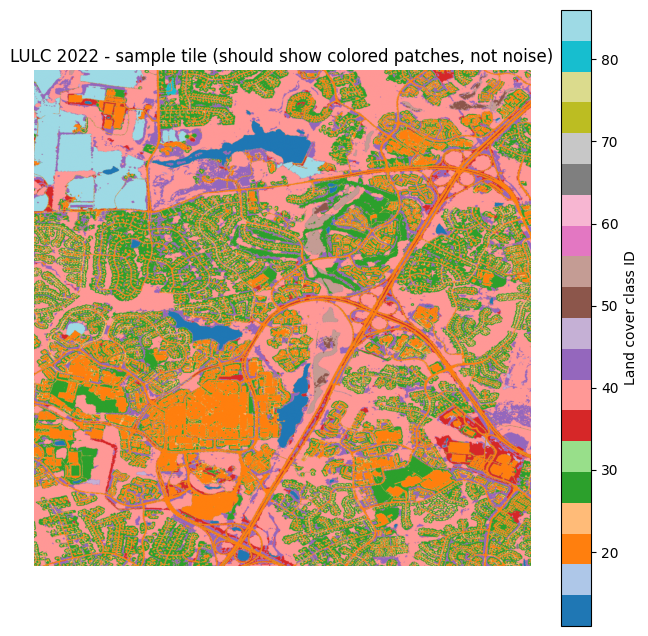

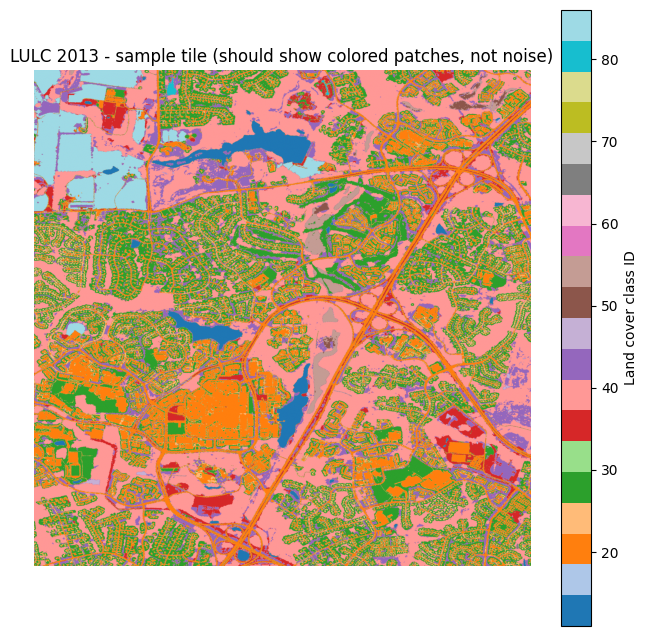

In [ ]:
# @title
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# Check how many tiles we got for each year
for year in ["2022", "2013"]:
    tiles = sorted(os.listdir(f"lulc_tiles/{year}"))
    print(f"{year}: {len(tiles)} tiles downloaded")

    # Open the first tile and look at its contents
    first_tile = f"lulc_tiles/{year}/{tiles[0]}"
    with rasterio.open(first_tile) as src:
        # LULC data is single band - one number per pixel representing the class
        data = src.read(1)
        print(f"  Tile size: {src.width} x {src.height} pixels")
        print(f"  Unique class values found: {np.unique(data)}")
        # ^ these numbers correspond to land cover classes
        # e.g. 10=tree canopy, 20=impervious road, 40=forest etc.

    # Visualize it so you can see if it looks right
    # tab20 is a colormap with 20 distinct colors, good for class data
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap="tab20")
    plt.colorbar(label="Land cover class ID")
    plt.title(f"LULC {year} - sample tile (should show colored patches, not noise)")
    plt.axis("off")
    plt.savefig(f"preview_lulc_{year}.png")
    print(f"  Saved preview_lulc_{year}.png — open this to visually check it looks right")

In [ ]:
# @title
import requests
import os

# The correct 2013/2014 LULC service URL - note lowercase and "publish" at the end
# This is different from the 2022 URL naming pattern which is why we had to find it
URL_2013 = "https://cicgis.org/arcgis/rest/services/Imagery/CBW_lulc_t1_2024_Edition_publish/ImageServer/exportImage"

# Baltimore County bounding box in lat/lon
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72
TILE_SIZE = 0.05

# Calculate grid size same as before
x_steps = int((EAST - WEST) / TILE_SIZE)
y_steps = int((NORTH - SOUTH) / TILE_SIZE)

# Delete the bad tiles we downloaded before with the wrong URL
# Those 80 files were only 62 bytes each so they're not real data
folder = "lulc_tiles/2013"
if os.path.exists(folder):
    old_tiles = os.listdir(folder)
    for f in old_tiles:
        fpath = f"{folder}/{f}"
        # Only delete files smaller than 1KB - those are definitely error responses not real tiles
        if os.path.getsize(fpath) < 1000:
            os.remove(fpath)
    print(f"Cleaned up bad tiles from previous attempt")

os.makedirs(folder, exist_ok=True)

success = 0
fail = 0
count = 0

print("--- Downloading 2013/2014 LULC ---")

for xi in range(x_steps):
    for yi in range(y_steps):

        # Calculate this tile's lat/lon boundaries
        w = WEST + xi * TILE_SIZE
        e = w + TILE_SIZE
        s = SOUTH + yi * TILE_SIZE
        n = s + TILE_SIZE

        fname = f"{folder}/tile_{xi:03d}_{yi:03d}.tif"

        # Skip tiles we already successfully downloaded
        if os.path.exists(fname) and os.path.getsize(fname) > 1000:
            print(f"  Skipping tile_{xi}_{yi} (already downloaded)")
            continue

        count += 1

        params = {
            "bbox": f"{w},{s},{e},{n}",
            "bboxSR": 4326,        # input coordinates are lat/lon
            "size": "2048,2048",   # output pixel dimensions
            "imageSR": 4326,       # output file in lat/lon
            "format": "tiff",      # GeoTIFF format
            "pixelType": "U8",     # pixel values are integers 0-255 (class IDs)
            "f": "image"           # return raw image, not JSON
        }

        try:
            r = requests.get(URL_2013, params=params, stream=True, timeout=120)

            if r.status_code == 200 and len(r.content) > 1000:
                # Only save if response is bigger than 1KB
                # Small responses are error messages disguised as 200 OK
                with open(fname, "wb") as f:
                    for chunk in r.iter_content(8192):
                        f.write(chunk)
                success += 1
                print(f"  [{count}] tile_{xi}_{yi} ✓")
            else:
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code}, {len(r.content)} bytes)")

        except Exception as e:
            fail += 1
            print(f"  [{count}] tile_{xi}_{yi} error: {e}")

print(f"\nDone: {success} downloaded, {fail} failed")
print("Now run the verification script to check a tile looks correct")

Cleaned up bad tiles from previous attempt
--- Downloading 2013/2014 LULC ---
  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [52] tile_5

Saved comparison_2013_vs_2022.png
The two maps should look mostly similar but with some differences where development happened


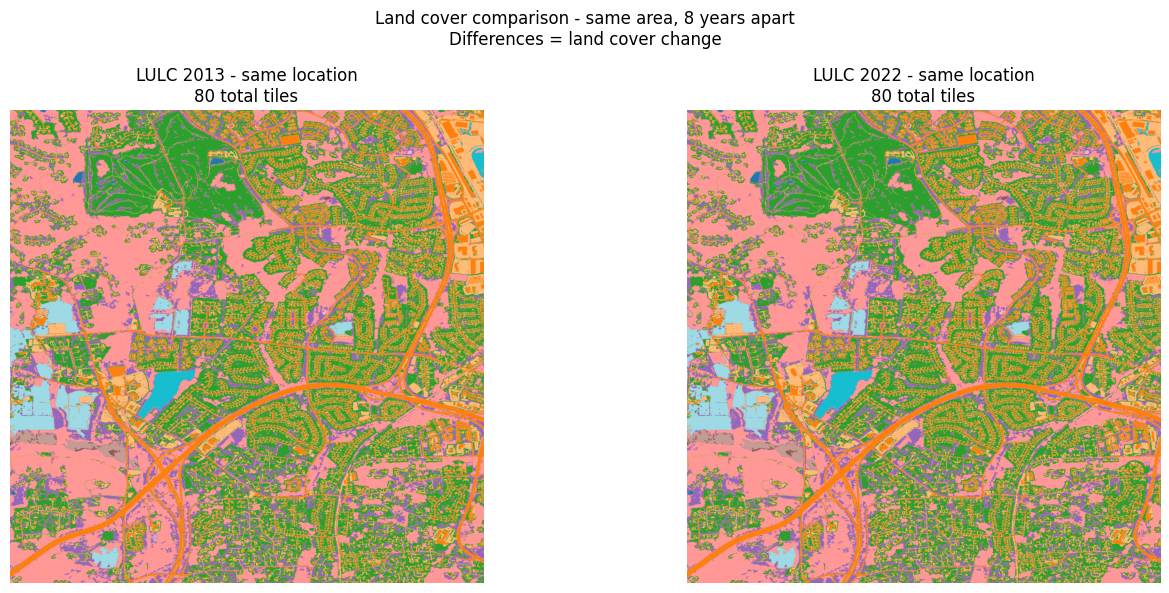

In [ ]:
# @title
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

# Check both years side by side so you can visually confirm they look different
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, year in enumerate(["2013", "2022"]):
    tiles = sorted(os.listdir(f"lulc_tiles/{year}"))

    # Find the same tile in both years so we're comparing the same area
    with rasterio.open(f"lulc_tiles/{year}/tile_004_004.tif") as src:
        data = src.read(1)

    axes[i].imshow(data, cmap="tab20", vmin=10, vmax=86)
    axes[i].set_title(f"LULC {year} - same location\n{len(tiles)} total tiles")
    axes[i].axis("off")

plt.suptitle("Land cover comparison - same area, 8 years apart\nDifferences = land cover change",
             fontsize=12)
plt.tight_layout()
plt.savefig("comparison_2013_vs_2022.png", dpi=150)
print("Saved comparison_2013_vs_2022.png")
print("The two maps should look mostly similar but with some differences where development happened")

Pixels that changed: 150,802
Percent of area that changed: 3.6%
Saved change_map.png


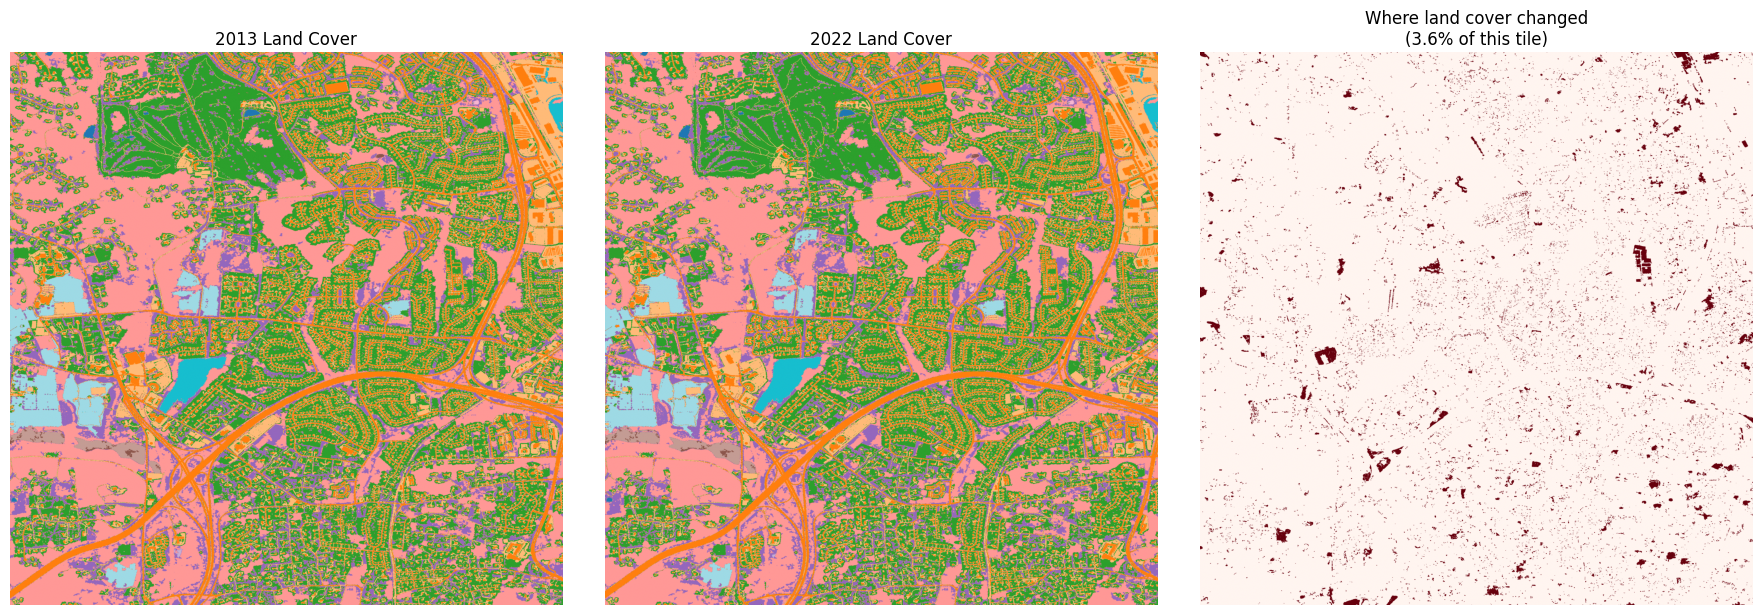

In [ ]:
# @title
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load the same tile from both years
with rasterio.open("lulc_tiles/2013/tile_004_004.tif") as src:
    data_2013 = src.read(1)

with rasterio.open("lulc_tiles/2022/tile_004_004.tif") as src:
    data_2022 = src.read(1)

# Create a change map - pixels that changed will be non-zero
# Pixels that stayed the same will be 0
change_map = (data_2013 != data_2022).astype(int)

# Calculate what percent of pixels actually changed
pct_changed = change_map.sum() / change_map.size * 100
print(f"Pixels that changed: {change_map.sum():,}")
print(f"Percent of area that changed: {pct_changed:.1f}%")

# Show all three maps together
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(data_2013, cmap="tab20", vmin=10, vmax=86)
axes[0].set_title("2013 Land Cover")
axes[0].axis("off")

axes[1].imshow(data_2022, cmap="tab20", vmin=10, vmax=86)
axes[1].set_title("2022 Land Cover")
axes[1].axis("off")

# Change map - white = no change, red = changed
axes[2].imshow(change_map, cmap="Reds")
axes[2].set_title(f"Where land cover changed\n({pct_changed:.1f}% of this tile)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("change_map.png", dpi=150)
print("Saved change_map.png")

__STEP 2: Download Maryland Aerial Imagery (3-inch, 5-band)__

In [ ]:
import requests
import os

os.makedirs("imagery_tiles", exist_ok=True)

# Maryland iMAP 3-inch aerial imagery REST service
# This is the same ExportImage approach as the LULC download
IMAGERY_URL = "https://mdgeodata.md.gov/imagery/rest/services/ThreeInch/MD_ThreeInchImagery/ImageServer/exportImage"

# IMPORTANT: Use the exact same bounding box and tile size as the LULC download
# This guarantees every imagery tile has a matching LULC tile with the same coverage
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72
TILE_SIZE = 0.05

x_steps = int((EAST - WEST) / TILE_SIZE)
y_steps = int((NORTH - SOUTH) / TILE_SIZE)

print(f"Downloading {x_steps * y_steps} imagery tiles...")
print("This will take longer than the LULC download because imagery files are bigger\n")

success = 0
fail = 0
count = 0

for xi in range(x_steps):
    for yi in range(y_steps):

        w = WEST + xi * TILE_SIZE
        e = w + TILE_SIZE
        s = SOUTH + yi * TILE_SIZE
        n = s + TILE_SIZE

        # Name matches LULC tiles exactly — tile_004_004 imagery lines up with
        # tile_004_004 LULC, making the pairing step trivial later
        fname = f"imagery_tiles/tile_{xi:03d}_{yi:03d}.tif"

        if os.path.exists(fname) and os.path.getsize(fname) > 1000:
            print(f"  Skipping tile_{xi}_{yi} (already exists)")
            continue

        count += 1

        params = {
            "bbox": f"{w},{s},{e},{n}",
            "bboxSR": 4326,       # coordinates are in lat/lon
            "size": "2048,2048",  # same pixel dimensions as LULC tiles
            "imageSR": 4326,      # output in lat/lon
            "format": "tiff",
            "pixelType": "U8",
            "bandIds": "0,1,2",
            "f": "image"
        }

        try:
            r = requests.get(IMAGERY_URL, params=params, stream=True, timeout=120)

            if r.status_code == 200 and len(r.content) > 1000:
                with open(fname, "wb") as f:
                    for chunk in r.iter_content(8192):
                        f.write(chunk)
                success += 1
                print(f"  [{count}] tile_{xi}_{yi} ✓")
            else:
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code})")

        except Exception as e:
            fail += 1
            print(f"  [{count}] tile_{xi}_{yi} error: {e}")

print(f"\nDone: {success} downloaded, {fail} failed")

This will take longer than the LULC download because imagery files are bigger

  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [52] tile_

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
import requests
import os
dir = "/content/drive/MyDrive/imagery_tiles_2013"
os.makedirs(dir, exist_ok=True)

# Maryland iMAP 3-inch aerial imagery REST service
# This is the same ExportImage approach as the LULC download
IMAGERY_URL = "https://mdgeodata.md.gov/imagery/rest/services/NAIP/NAIPImagery2013/ImageServer/exportImage"

# IMPORTANT: Use the exact same bounding box and tile size as the LULC download
# This guarantees every imagery tile has a matching LULC tile with the same coverage
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72
TILE_SIZE = 0.05

x_steps = int((EAST - WEST) / TILE_SIZE)
y_steps = int((NORTH - SOUTH) / TILE_SIZE)

print(f"Downloading {x_steps * y_steps} imagery tiles...")
print("This will take longer than the LULC download because imagery files are bigger\n")

success = 0
fail = 0
count = 0

for xi in range(x_steps):
    for yi in range(y_steps):

        w = WEST + xi * TILE_SIZE
        e = w + TILE_SIZE
        s = SOUTH + yi * TILE_SIZE
        n = s + TILE_SIZE

        # Name matches LULC tiles exactly — tile_004_004 imagery lines up with
        # tile_004_004 LULC, making the pairing step trivial later
        fname = f"{dir}/tile_{xi:03d}_{yi:03d}.tif"

        if os.path.exists(fname) and os.path.getsize(fname) > 1000:
            print(f"  Skipping tile_{xi}_{yi} (already exists)")
            continue

        count += 1

        params = {
            "bbox": f"{w},{s},{e},{n}",
            "bboxSR": 4326,       # coordinates are in lat/lon
            "size": "2048,2048",  # same pixel dimensions as LULC tiles
            "imageSR": 4326,      # output in lat/lon
            "format": "tiff",
            "pixelType": "U8",
            "bandIds": "0,1,2",
            "f": "image"
        }

        try:
            r = requests.get(IMAGERY_URL, params=params, stream=True, timeout=120)

            if r.status_code == 200 and len(r.content) > 1000:
                with open(fname, "wb") as f:
                    for chunk in r.iter_content(8192):
                        f.write(chunk)
                success += 1
                print(f"  [{count}] tile_{xi}_{yi} ✓")
            else:
                fail += 1
                print(f"  [{count}] tile_{xi}_{yi} failed ({r.status_code})")

        except Exception as e:
            fail += 1
            print(f"  [{count}] tile_{xi}_{yi} error: {e}")

print(f"\nDone: {success} downloaded, {fail} failed")

This will take longer than the LULC download because imagery files are bigger

  [1] tile_0_0 ✓
  [2] tile_0_1 ✓
  [3] tile_0_2 ✓
  [4] tile_0_3 ✓
  [5] tile_0_4 ✓
  [6] tile_0_5 ✓
  [7] tile_0_6 ✓
  [8] tile_0_7 ✓
  [9] tile_0_8 ✓
  [10] tile_0_9 ✓
  [11] tile_1_0 ✓
  [12] tile_1_1 ✓
  [13] tile_1_2 ✓
  [14] tile_1_3 ✓
  [15] tile_1_4 ✓
  [16] tile_1_5 ✓
  [17] tile_1_6 ✓
  [18] tile_1_7 ✓
  [19] tile_1_8 ✓
  [20] tile_1_9 ✓
  [21] tile_2_0 ✓
  [22] tile_2_1 ✓
  [23] tile_2_2 ✓
  [24] tile_2_3 ✓
  [25] tile_2_4 ✓
  [26] tile_2_5 ✓
  [27] tile_2_6 ✓
  [28] tile_2_7 ✓
  [29] tile_2_8 ✓
  [30] tile_2_9 ✓
  [31] tile_3_0 ✓
  [32] tile_3_1 ✓
  [33] tile_3_2 ✓
  [34] tile_3_3 ✓
  [35] tile_3_4 ✓
  [36] tile_3_5 ✓
  [37] tile_3_6 ✓
  [38] tile_3_7 ✓
  [39] tile_3_8 ✓
  [40] tile_3_9 ✓
  [41] tile_4_0 ✓
  [42] tile_4_1 ✓
  [43] tile_4_2 ✓
  [44] tile_4_3 ✓
  [45] tile_4_4 ✓
  [46] tile_4_5 ✓
  [47] tile_4_6 ✓
  [48] tile_4_7 ✓
  [49] tile_4_8 ✓
  [50] tile_4_9 ✓
  [51] tile_5_0 ✓
  [52] tile_

Imagery tiles: 80
LULC tiles:    80

Imagery tile info:
  Bands: 5
  Size: 2048 x 2048
  CRS: EPSG:4326

Saved imagery_vs_lulc.png
The two images should cover the exact same geographic area


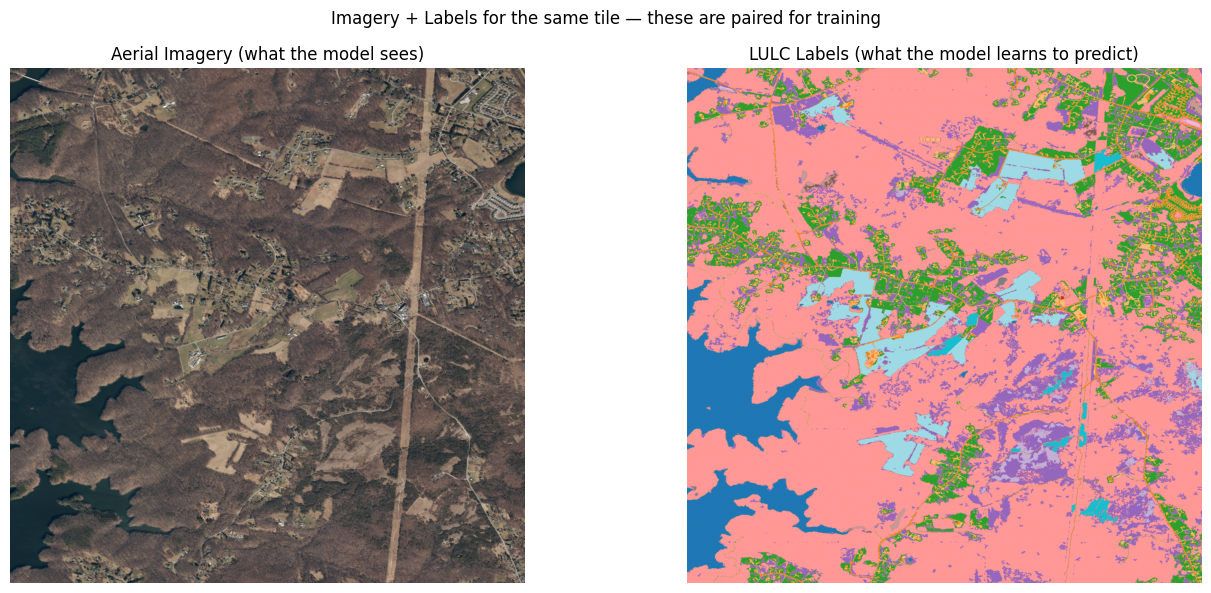

In [ ]:
# @title
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Check we got tiles and they have the right number of bands
imagery_tiles = sorted(os.listdir("imagery_tiles"))
lulc_tiles = sorted(os.listdir("lulc_tiles/2022"))
print(f"Imagery tiles: {len(imagery_tiles)}")
print(f"LULC tiles:    {len(lulc_tiles)}")

# Open one imagery tile and check it
with rasterio.open(f"imagery_tiles/{imagery_tiles[4]}") as src:
    print(f"\nImagery tile info:")
    print(f"  Bands: {src.count}")  # should be 4 or 5 (RGB + NIR)
    print(f"  Size: {src.width} x {src.height}")
    print(f"  CRS: {src.crs}")
    rgb = src.read([1, 2, 3])  # read just RGB for preview

# Show imagery and its matching LULC label side by side
with rasterio.open(f"lulc_tiles/2022/{lulc_tiles[4]}") as src:
    lulc = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rgb_display = np.moveaxis(rgb, 0, -1)
rgb_display = (rgb_display / rgb_display.max() * 255).astype("uint8")
axes[0].imshow(rgb_display)
axes[0].set_title("Aerial Imagery (what the model sees)")
axes[0].axis("off")

axes[1].imshow(lulc, cmap="tab20", vmin=10, vmax=86)
axes[1].set_title("LULC Labels (what the model learns to predict)")
axes[1].axis("off")

plt.suptitle("Imagery + Labels for the same tile — these are paired for training", fontsize=12)
plt.tight_layout()
plt.savefig("imagery_vs_lulc.png", dpi=150)
print("\nSaved imagery_vs_lulc.png")
print("The two images should cover the exact same geographic area")

In [ ]:
!pip install osmnx
!pip install geocube
!pip install geoai-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 20.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1

In [ ]:
# @title
import osmnx as ox
import pandas as pd
from geocube.api.core import make_geocube
from shapely.geometry import box

# Define the same bounds as your imagery script
WEST, SOUTH, EAST, NORTH = -76.88, 39.20, -76.45, 39.72
bbox = (WEST, SOUTH, EAST, NORTH)

# Fetch landuse tags within the total bounding box
tags = {'landuse': True, 'leisure': True, 'natural': ['water', 'wood']}
gdf = ox.features_from_bbox(bbox, tags)

# Convert labels to integer IDs for the model
# 0 is usually reserved for 'Background' or 'No Data'
gdf['label'] = gdf['landuse'].fillna(gdf['leisure']).fillna(gdf['natural'])
gdf['label_id'] = gdf['label'].astype('category').cat.codes + 1

# Save the mapping so you know which ID is which class
label_mapping = dict(enumerate(gdf['label'].astype('category').cat.categories, 1))
print("Label Mapping:", label_mapping)

Label Mapping: {1: 'allotments', 2: 'amusement_arcade', 3: 'animal_keeping', 4: 'apiary', 5: 'axe_throwing', 6: 'bandstand', 7: 'basin', 8: 'bird_hide', 9: 'bleacher', 10: 'bleachers', 11: 'bowling_alley', 12: 'brownfield', 13: 'cemetery', 14: 'civic', 15: 'civic_admin', 16: 'commercial', 17: 'common', 18: 'construction', 19: 'dance', 20: 'depot', 21: 'disc_golf_course', 22: 'dog_park', 23: 'education', 24: 'emergency', 25: 'escape_game', 26: 'farm', 27: 'farmland', 28: 'farmyard', 29: 'firepit', 30: 'fishing', 31: 'fitness_centre', 32: 'fitness_station', 33: 'flowerbed', 34: 'forest', 35: 'garages', 36: 'garden', 37: 'golf_course', 38: 'grass', 39: 'greenfield', 40: 'greenhouse_horticulture', 41: 'hackerspace', 42: 'harbour', 43: 'highway', 44: 'horse_riding', 45: 'hot_tub', 46: 'ice_rink', 47: 'indoor_play', 48: 'industrial', 49: 'institutional', 50: 'landfill', 51: 'logistics', 52: 'marina', 53: 'maze', 54: 'meadow', 55: 'military', 56: 'miniature_golf', 57: 'mixed', 58: 'nature_res

In [ ]:
# @title
# 1. Define your mapping dictionary
reclass_dict = {
    # DEVELOPED
    'residential': 1, 'commercial': 1, 'industrial': 1, 'retail': 1, 'civic': 1,
    'education': 1, 'religious': 1, 'public_building': 1, 'institutional': 1,
    # TRANSPORT
    'highway': 2, 'railway': 2, 'depot': 2, 'garages': 2,
    # FOREST
    'forest': 3, 'wood': 3, 'nature_reserve': 3,
    # GRASS/LEISURE
    'grass': 4, 'park': 4, 'meadow': 4, 'golf_course': 4, 'pitch': 4, 'cemetery': 4,
    'playground': 4, 'recreation_ground': 4, 'common': 4, 'garden': 4,
    # AGRICULTURE
    'farmland': 5, 'farmyard': 5, 'orchard': 5, 'vineyard': 5, 'allotments': 5,
    # WATER
    'water': 6, 'basin': 6, 'reservoir_watershed': 6, 'marina': 6,
    # BARREN/OTHER
    'quarry': 7, 'construction': 7, 'brownfield': 7, 'landfill': 7
}

# 2. Apply mapping to the GeoDataFrame
# Any tag not in the dictionary will become NaN (which we fill with 0)
gdf['label_id'] = gdf['landuse'].map(reclass_dict).fillna(0).astype(int)
gdf['geometry'] = gdf['geometry'].buffer(0)


In [ ]:
print(gdf.crs) # Should say EPSG:4326
print(gdf.total_bounds) # Should be within your WEST, SOUTH, EAST, NORTH range

epsg:4326
[-76.9586574  39.1548604 -76.3586447  39.7338169]


In [ ]:
# @title
import xarray as xr
import numpy as np
os.makedirs("mask_tiles", exist_ok=True)
for xi in range(x_steps):
    for yi in range(y_steps):
        w = WEST + xi * TILE_SIZE
        e = w + TILE_SIZE
        s = SOUTH + yi * TILE_SIZE
        n = s + TILE_SIZE

        mask_fname = f"mask_tiles/tile_{xi:03d}_{yi:03d}.tif"

        # 1. Fix the geometries on the fly
        tile_geom = box(w, s, e, n)
        subset = gdf.clip(tile_geom)
        subset['geometry'] = subset.geometry.buffer(0)

        # 2. Create the Template (Crucial for alignment)
        y_coords = np.linspace(n, s, 2048)
        x_coords = np.linspace(w, e, 2048)
        template = xr.DataArray(
            data=np.zeros((2048, 2048), dtype="uint8"),
            coords={"y": y_coords, "x": x_coords},
            dims=("y", "x")
        ).rio.write_crs("EPSG:4326")

        if not subset.empty:
            try:
                # Use 'like' to force the data into the template
                out_grid = make_geocube(
                    vector_data=subset,
                    measurements=["label_id"],
                    like=template,
                    fill=0
                )
                # Save the mask
                out_grid.label_id.astype("uint8").rio.to_raster(mask_fname)
            except Exception as e:
                # If geocube fails, save a blank mask so the folder stays in sync
                template.rio.to_raster(mask_fname)
        else:
            # NO DATA found by clip - Save blank mask
            template.rio.to_raster(mask_fname)

In [ ]:
import os
import rasterio
import numpy as np

# --- CONFIGURATION ---
input_folder = '/content/lulc_tiles/2022'
output_folder = '/content/lulc_tiles/2022_reclassed'

# Ensure output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

reclass_map = {
    # Water (Now 0)
    10: 0, 11: 0, 12: 0, 13: 0, 14: 0,

    # Developed (Now 1)
    20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1,
    30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1,

    # Natural
    15: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 2, 45: 2, 46: 2,
    50: 2, 51: 2, 52: 2, 53: 2, 54: 2, 55: 2,
    60: 2, 61: 2, 62: 2, 63: 2, 64: 2, 65: 2,
    70: 2, 71: 2, 72: 2, 73: 2, 74: 2, 75: 2,

    # Agriculture (Now 3)
    80: 3, 81: 3, 82: 3, 83: 3, 84: 3, 85: 3, 86: 3
}

# Pre-calculate a lookup array for extreme speed (works for values 0-255)
lookup = np.zeros(256, dtype=np.uint8)
for old_val, new_val in reclass_map.items():
    lookup[old_val] = new_val

# --- PROCESSING ---
for filename in os.listdir(input_folder):
    if filename.endswith(".tif") or filename.endswith(".tiff"):
        in_path = os.path.join(input_folder, filename)
        out_path = os.path.join(output_folder, f"{filename}")

        print(f"Processing: {filename}...")

        with rasterio.open(in_path) as src:
            meta = src.meta.copy()
            meta.update({
                'dtype': 'uint8',
                'nodata': 0,
                'compress': 'lzw',
                'count': 1
            })

            with rasterio.open(out_path, 'w', **meta) as dst:
                # Process in blocks (windows) to save RAM
                for ij, window in src.block_windows():
                    # Read the chunk
                    block = src.read(1, window=window)

                    # Apply reclassification using the lookup array
                    # This is much faster than a python loop or .get()
                    reclassed_block = lookup[block]

                    # Write the chunk
                    dst.write(reclassed_block, 1, window=window)

print("Batch processing complete!")

Processing: tile_002_006.tif...
Processing: tile_003_000.tif...
Processing: tile_005_005.tif...
Processing: tile_007_009.tif...
Processing: tile_002_001.tif...
Processing: tile_001_007.tif...
Processing: tile_004_008.tif...
Processing: tile_007_006.tif...
Processing: tile_000_002.tif...
Processing: tile_003_007.tif...
Processing: tile_005_002.tif...
Processing: tile_003_001.tif...
Processing: tile_001_003.tif...
Processing: tile_001_001.tif...
Processing: tile_002_005.tif...
Processing: tile_006_004.tif...
Processing: tile_005_004.tif...
Processing: tile_000_008.tif...
Processing: tile_007_004.tif...
Processing: tile_004_000.tif...
Processing: tile_004_004.tif...
Processing: tile_003_008.tif...
Processing: tile_002_009.tif...
Processing: tile_005_007.tif...
Processing: tile_006_000.tif...
Processing: tile_001_004.tif...
Processing: tile_004_003.tif...
Processing: tile_002_007.tif...
Processing: tile_000_000.tif...
Processing: tile_003_003.tif...
Processing: tile_002_003.tif...
Processi

In [3]:
import os
import rasterio
import numpy as np

# --- CONFIGURATION ---
input_folder = '/content/lulc_tiles/2013'
output_folder = '/content/lulc_tiles/2013_reclassed'

# Ensure output folder exists
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 1: Water | 2: Developed | 3: Natural/Forest | 4: Wetlands | 5: Agriculture
# SHIFTED MAP (to fix the +1 class error)
# 0: Water | 1: Developed | 2: Natural/Forest | 3: Wetlands | 4: Agriculture
reclass_map = {
    # Water (Now 0)
    10: 0, 11: 0, 12: 0, 13: 0, 14: 0,

    # Developed (Now 1)
    20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1,
    30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1,

    # Natural / Forest (Now 2)
    15: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 2, 45: 2, 46: 2,

    # Wetlands (Now 2)
    50: 2, 51: 2, 52: 2, 53: 2, 54: 2, 55: 2,
    60: 2, 61: 2, 62: 2, 63: 2, 64: 2, 65: 2,
    70: 2, 71: 2, 72: 2, 73: 2, 74: 2, 75: 2,

    # Agriculture (Now 3)
    80: 3, 81: 3, 82: 3, 83: 3, 84: 3, 85: 3, 86: 3
}

# Pre-calculate a lookup array for extreme speed (works for values 0-255)
lookup = np.zeros(256, dtype=np.uint8)
for old_val, new_val in reclass_map.items():
    lookup[old_val] = new_val

# --- PROCESSING ---
for filename in os.listdir(input_folder):
    if filename.endswith(".tif") or filename.endswith(".tiff"):
        in_path = os.path.join(input_folder, filename)
        out_path = os.path.join(output_folder, f"{filename}")

        print(f"Processing: {filename}...")

        with rasterio.open(in_path) as src:
            meta = src.meta.copy()
            meta.update({
                'dtype': 'uint8',
                'nodata': 0,
                'compress': 'lzw',
                'count': 1
            })

            with rasterio.open(out_path, 'w', **meta) as dst:
                # Process in blocks (windows) to save RAM
                for ij, window in src.block_windows():
                    # Read the chunk
                    block = src.read(1, window=window)

                    # Apply reclassification using the lookup array
                    # This is much faster than a python loop or .get()
                    reclassed_block = lookup[block]

                    # Write the chunk
                    dst.write(reclassed_block, 1, window=window)

print("Batch processing complete!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/lulc_tiles/2013'

In [11]:
import os
import glob
import leafmap

# Define your directories and mask
dir_paths = ["/content/drive/MyDrive/imagery_tiles",
             "/content/drive/MyDrive/lulc_tiles/2013_reclassed",
             "/content/drive/MyDrive/lulc_tiles/2022_reclassed"]
geojson_mask = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"

for input_dir in dir_paths:
  output_dir = f"{input_dir}_clipped"
  os.makedirs(output_dir, exist_ok=True)

  # Find all TIFF files in the input directory
  tif_files = glob.glob(os.path.join(input_dir, "*.tif"))

  print(f"Found {len(tif_files)} TIFFs. Starting clipping process...")

  for tif in tif_files:
      filename = os.path.basename(tif)
      out_path = os.path.join(output_dir, filename)

      try:
          # Clip the individual TIFF
          leafmap.clip_image(
              image=tif,
              mask=geojson_mask,
              output=out_path
          )
          print(f"Successfully clipped: {filename}")

      except Exception as e:
          # If the TIFF doesn't intersect the GeoJSON, skip it
          print(e)

Found 80 TIFFs. Starting clipping process...


Reading input: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_003.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_003.tif


Successfully clipped: tile_000_003.tif


Reading input: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_004.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/imagery_tiles_clipped/tile_000_004.tif


Successfully clipped: tile_000_004.tif


...

Successfully clipped: tile_000_009.tif


Reading input: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_003_004.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_003_004.tif


Successfully clipped: tile_003_004.tif


Reading input: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_005_008.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped/tile_005_008.tif


Successfully clipped: tile_005_008.tif


In [23]:
import leafmap
leafmap.merge_rasters("/content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped", output="full_landcover_predicted_2023.tif")

Merging 80 rasters into 'full_landcover_predicted_2023.tif'...
Raster merge completed successfully: full_landcover_predicted_2023.tif


In [5]:
import os
import geoai

# Use the directories we created in the previous steps
imagery_dir = "/content/drive/MyDrive/imagery_tiles_clipped"
mask_dir = "/content/drive/MyDrive/lulc_tiles/2022_reclassed_clipped"
out_folder = "/content/drive/MyDrive/baltimore_training_data"

# geoai uses 'export_geotiff_tiles' to create smaller training chips (e.g., 512x512)
# from your larger 2048x2048 tiles.
for img_file in os.listdir(imagery_dir):
    if img_file.endswith(".tif"):
        tile_id = img_file.replace(".tif", "")
        img_path = os.path.join(imagery_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file) # Names match exactly

        # Create 512x512 chips for the AI model
        geoai.export_geotiff_tiles(
            in_raster=img_path,
            out_folder=out_folder,
            in_class_data=mask_path,
            tile_size=512,
            stride=384, # 50% overlap for better training
        )

Generated: 25, With features: 18: 100%|██████████| 25/25 [00:02<00:00,  9.74it/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content/

baltimore_training_data  drive		imagery_tiles_2013  sample_data
cache			 imagery_tiles	mask_tiles


In [ ]:
# -r means recursive (includes everything inside)
# -v means verbose (shows you what is happening)

!cp -rv "/content/baltimore_training_data" "/content/imagery_tiles" "/content/imagery_tiles" "/content/mask_tiles" "/content/lulc_tiles" /content/drive/MyDrive/

'/content/baltimore_training_data/images/tile_000037.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000037.tif'
'/content/baltimore_training_data/images/tile_000021.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000021.tif'
'/content/baltimore_training_data/images/tile_000000.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000000.tif'
'/content/baltimore_training_data/images/tile_000001.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000001.tif'
'/content/baltimore_training_data/images/tile_000002.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000002.tif'
'/content/baltimore_training_data/images/tile_000003.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000003.tif'
'/content/baltimore_training_data/images/tile_000004.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000004.tif'
'/content/baltimore_training_data/images/tile_000005.tif' -> '/conten

In [ ]:
# @title
# Train the model on your Baltimore data
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/baltimore_models",
    num_channels=3,      # Set to 3 for standard RGB imagery
    num_classes=6,       # Updated for your 0-7 classes
    batch_size=8,
    num_epochs=4,
    loss_function="unified_focal",  # or "dice", "tversky", "focal", "crossentropy"
    # Unified Focal Loss parameters
    ufl_lambda=0.5,   # balance: 0.0=pure region, 1.0=pure distribution
    ufl_gamma=0.75,    # focusing parameter
    ufl_delta=0.7,     # FN weight (>0.5 = recall-focused)
    # Class weighting
    use_class_weights=True,  # auto-compute inverse-frequency weights
    ignore_index=0,          # ignore background class
)

In [13]:
# Updated for Baltimore Landcover Training
import geoai
# Use the directories we created in the previous steps
imagery_dir = "/content/drive/MyDrive/imagery_tiles"
mask_dir = "lulc_tiles//content/drive/MyDrive/lulc_tiles"
out_folder = "/content/drive/MyDrive/baltimore_training_data"
previous_model = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_2/best_model.pth"

geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/baltimore_models_2",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    checkpoint_path=previous_model,
    num_channels=3,
    num_classes=4,
    batch_size=16,
    num_epochs=300,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True
  )

In [14]:
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/baltimore_models_2",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    checkpoint_path=previous_model,
    num_channels=3,
    num_classes=4,
    batch_size=16,
    num_epochs=30,
    learning_rate=0.0001,
    val_split=0.2,
    verbose=True
  )

In [15]:
test_tile = "/content/drive/MyDrive/imagery_tiles/tile_000_005.tif" # Pick a tile to test
output_mask = "prediction_000_005.tif"

geoai.semantic_segmentation(
    input_path=test_tile,
    output_path=output_mask,
    model_path=f"{out_folder}/baltimore_models_2/best_model.pth",
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256
)

64it [00:01, 32.14it/s]


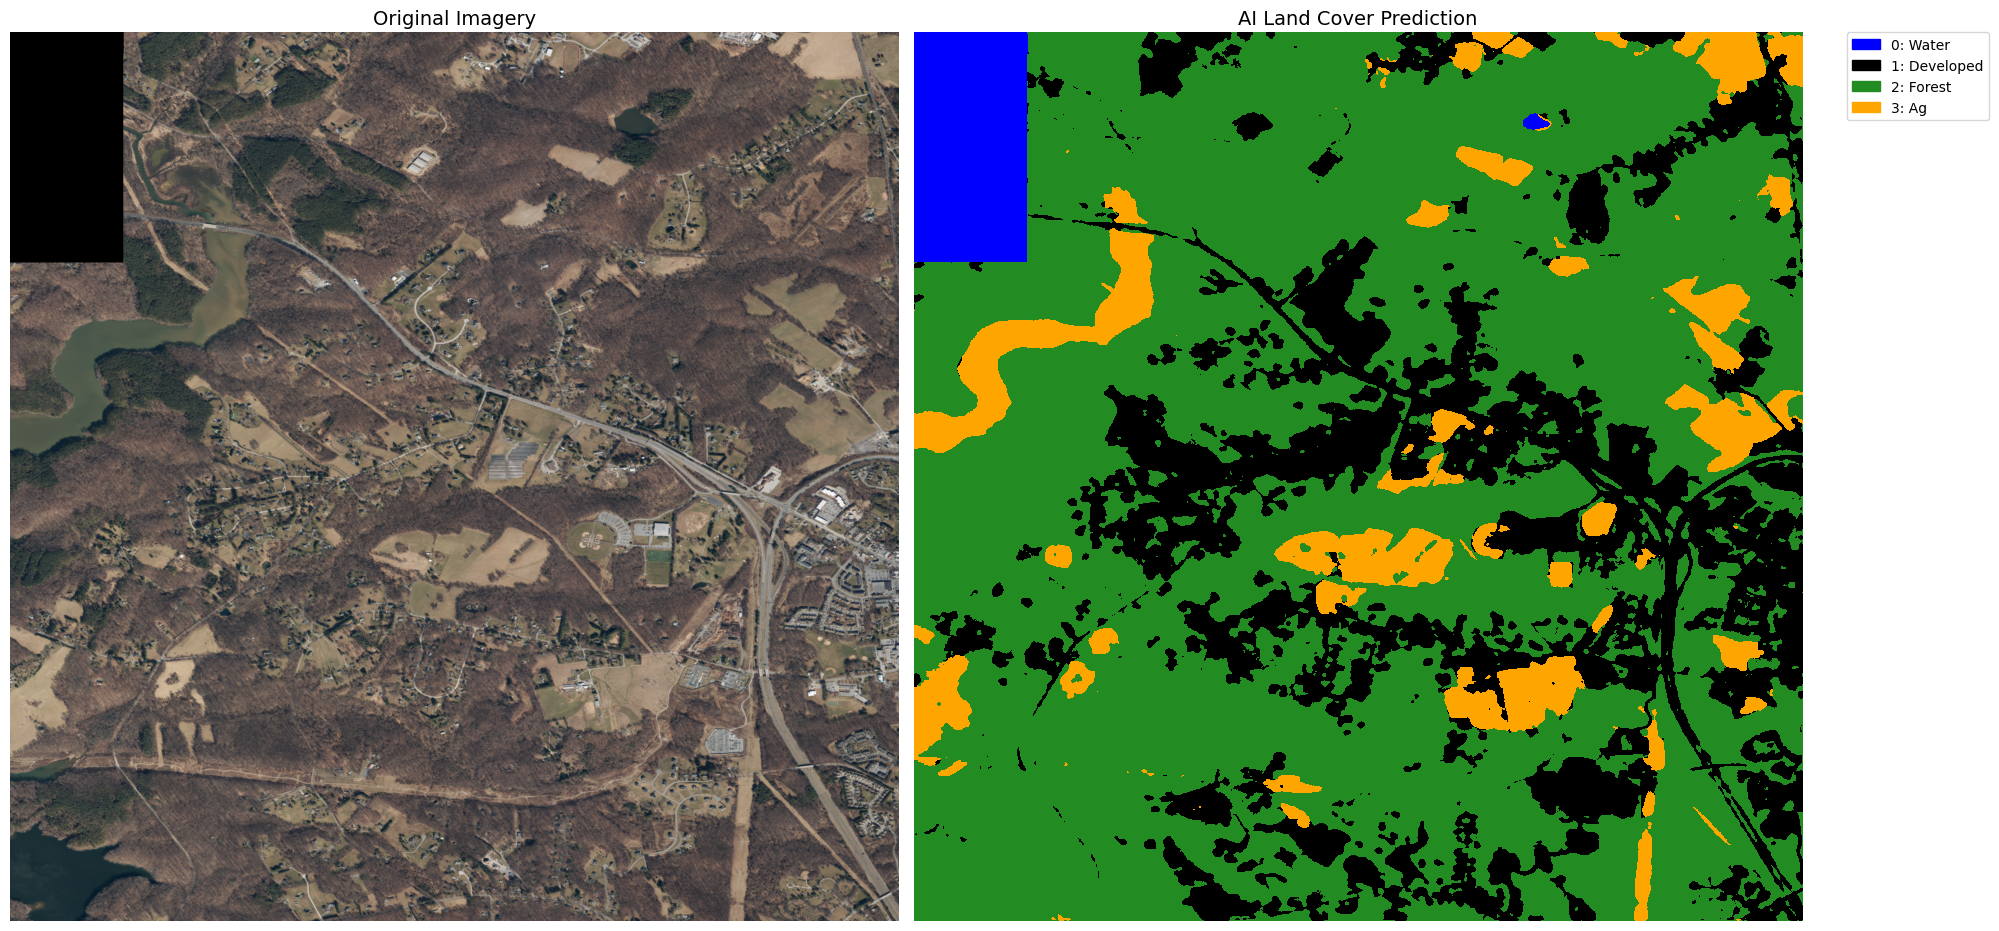

Unique IDs found in this prediction: [0 1 2 3]


In [16]:
import matplotlib.pyplot as plt
import rioxarray
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# 1. Setup paths


# 2. Define the Color Map and Boundaries
# Updated to 5 classes to account for 0:Background/Unlabeled
osm_colors = ["blue", "black", "forestgreen", "orange"]
osm_labels = ["Water", "Developed", "Forest", "Ag"]
custom_cmap = ListedColormap(osm_colors)

# Create boundaries: [0, 1) is black, [1, 2) is blue, etc.
bounds = [0, 1, 2, 3, 4]
norm = BoundaryNorm(bounds, custom_cmap.N)

# 3. Load the data
img = rioxarray.open_rasterio(test_tile)
pred = rioxarray.open_rasterio(output_mask).squeeze()

# 4. Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# --- Plot Imagery ---
img_display = img.transpose("y", "x", "band")
if img_display.max() > 1:
    img_display = img_display / 255.0

ax1.imshow(img_display)
ax1.set_title(f"Original Imagery", fontsize=14)
ax1.axis('off')

# --- Plot Prediction ---
# Use 'norm' instead of vmin/vmax to fix the color stretching
im2 = ax2.imshow(pred, cmap=custom_cmap, norm=norm, interpolation='nearest')
ax2.set_title("AI Land Cover Prediction", fontsize=14)
ax2.axis('off')

# 5. Add Legend (Dynamically linked to osm_labels)
legend_patches = [
    mpatches.Patch(color=osm_colors[i], label=f"{i}: {osm_labels[i]}")
    for i in range(len(osm_labels))
]
ax2.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# Quick Debug check
print("Unique IDs found in this prediction:", np.unique(pred.values))

In [20]:
# Setup directories
output_dir = "prediction_results_2023"
os.makedirs(output_dir, exist_ok=True)
model_path = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_2/best_model.pth"
# Run batch inference
geoai.semantic_segmentation_batch(
    input_dir=imagery_dir,
    output_dir=output_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256,
    batch_size=4
)

64it [00:01, 32.00it/s]
64it [00:02, 31.35it/s]
64it [00:01, 36.04it/s]
64it [00:01, 34.92it/s]
64it [00:01, 34.90it/s]
64it [00:01, 34.29it/s]
64it [00:02, 31.88it/s]
64it [00:01, 33.92it/s]
64it [00:01, 35.91it/s]
64it [00:01, 37.60it/s]
64it [00:01, 34.45it/s]
64it [00:01, 32.55it/s]
64it [00:02, 31.68it/s]
64it [00:01, 35.51it/s]
64it [00:01, 34.99it/s]
64it [00:01, 32.78it/s]
64it [00:02, 31.79it/s]
64it [00:01, 34.58it/s]
64it [00:01, 34.64it/s]
64it [00:02, 30.55it/s]
64it [00:01, 34.96it/s]
64it [00:02, 31.48it/s]
64it [00:01, 33.68it/s]
64it [00:02, 30.66it/s]
64it [00:01, 35.63it/s]
64it [00:01, 34.69it/s]
64it [00:02, 31.50it/s]
64it [00:01, 35.54it/s]
64it [00:01, 35.71it/s]
64it [00:01, 34.82it/s]
64it [00:01, 35.93it/s]
64it [00:01, 32.28it/s]
64it [00:02, 28.15it/s]
64it [00:01, 35.48it/s]
64it [00:01, 34.91it/s]
64it [00:01, 34.92it/s]
64it [00:02, 31.52it/s]
64it [00:01, 35.14it/s]
64it [00:01, 35.27it/s]
64it [00:01, 35.56it/s]
64it [00:01, 34.94it/s]
64it [00:02, 31.

In [7]:
import leafmap
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023.tif"
leafmap.merge_rasters(output_dir, output=output_image)

NameError: name 'output_dir' is not defined

In [4]:
import leafmap
input_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023.tif"
geojson_mask = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif"

leafmap.clip_image(
    image=input_image,
    mask=geojson_mask,
    output=output_image
)

Reading input: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif


In [26]:
# Setup directories
output_dir = "prediction_results_2013"
imagery_dir = "/content/drive/MyDrive/imagery_tiles_2013"
os.makedirs(output_dir, exist_ok=True)
model_path = "/content/drive/MyDrive/baltimore_training_data/baltimore_models_2/best_model.pth"
# Run batch inference
geoai.semantic_segmentation_batch(
    input_dir=imagery_dir,
    output_dir=output_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256,
    batch_size=4
)

64it [00:02, 31.79it/s]
64it [00:01, 37.01it/s]
64it [00:01, 37.03it/s]
64it [00:01, 36.35it/s]
64it [00:01, 36.67it/s]
64it [00:01, 32.84it/s]
64it [00:01, 34.96it/s]
64it [00:01, 36.22it/s]
64it [00:01, 36.26it/s]
64it [00:01, 36.31it/s]
64it [00:01, 34.90it/s]
64it [00:01, 32.71it/s]
64it [00:01, 36.38it/s]
64it [00:01, 36.60it/s]
64it [00:01, 36.32it/s]
64it [00:01, 36.08it/s]
64it [00:01, 32.56it/s]
64it [00:02, 23.55it/s]
64it [00:01, 34.51it/s]
64it [00:01, 36.34it/s]
64it [00:02, 23.38it/s]
64it [00:02, 30.60it/s]
64it [00:01, 36.70it/s]
64it [00:01, 36.68it/s]
64it [00:01, 35.85it/s]
64it [00:01, 33.34it/s]
64it [00:01, 36.73it/s]
64it [00:01, 36.37it/s]
64it [00:01, 36.37it/s]
64it [00:01, 36.74it/s]
64it [00:01, 33.79it/s]
64it [00:01, 33.58it/s]
64it [00:01, 36.55it/s]
64it [00:01, 36.64it/s]
64it [00:01, 36.87it/s]
64it [00:01, 33.50it/s]
64it [00:01, 33.41it/s]
64it [00:01, 36.62it/s]
64it [00:01, 37.03it/s]
64it [00:01, 35.67it/s]
64it [00:01, 36.24it/s]
64it [00:01, 33.

In [8]:
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif"
output_dir = "prediction_results_2013"
leafmap.merge_rasters(output_dir, output=output_image)

Merging 80 rasters into '/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif'...
Raster merge completed successfully: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif


In [9]:
import leafmap
input_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013.tif"
geojson_mask = "/content/drive/MyDrive/Urban_Rural_Demarcation_Line.geojson"
output_image = "/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif"

leafmap.clip_image(
    image=input_image,
    mask=geojson_mask,
    output=output_image
)

Reading input: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif

Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif


In [22]:
# @title
break
import os
import rioxarray
import numpy as np

input_dir = "imagery_tiles_2013"
output_dir = "imagery_tiles_2013_transposed"
os.makedirs(output_dir, exist_ok=True)

all_tiles = [f for f in os.listdir(input_dir) if f.endswith(".tif")]

for tile in all_tiles:
    path = os.path.join(input_dir, tile)

    # Load the raster
    rds = rioxarray.open_rasterio(path)

    # Check current shape
    # If it's (H, W, B), we move the 'band' to the front
    if rds.ndim == 3:
        # rioxarray usually opens as (band, y, x)
        # If your prediction failed, you might need to force the transpose:
        transposed = rds.transpose("band", "y", "x")

        # Save the corrected version
        output_path = os.path.join(output_dir, tile)
        transposed.rio.to_raster(output_path)
        print(f"✓ Transposed {tile}")

FileNotFoundError: [Errno 2] No such file or directory: 'imagery_tiles_2013'

In [ ]:
import geoai
input_dir = "imagery_tiles_2013"
output_dir = "prediction_results_2013"
model_path = "baltimore_training_data/baltimore_models_1/best_model.pth"

# Run batch inference
geoai.semantic_segmentation_batch(
    input_dir=input_dir,
    output_dir=output_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=4,
    window_size=512,
    overlap=256,
    batch_size=4
)

64it [00:02, 24.93it/s]
64it [00:03, 18.62it/s]
64it [00:01, 35.68it/s]
64it [00:01, 36.33it/s]
64it [00:01, 35.69it/s]
64it [00:01, 36.35it/s]
64it [00:01, 33.49it/s]
64it [00:02, 26.84it/s]
64it [00:02, 25.46it/s]
64it [00:01, 33.27it/s]
64it [00:01, 35.48it/s]
64it [00:01, 36.44it/s]
64it [00:01, 35.51it/s]
64it [00:01, 32.82it/s]
64it [00:02, 29.00it/s]
64it [00:02, 25.04it/s]
64it [00:02, 24.66it/s]
64it [00:01, 35.60it/s]
64it [00:01, 35.96it/s]
64it [00:01, 35.37it/s]
64it [00:01, 32.80it/s]
64it [00:02, 30.60it/s]
64it [00:02, 24.29it/s]
64it [00:02, 24.32it/s]
64it [00:01, 35.96it/s]
64it [00:01, 35.52it/s]
64it [00:01, 35.79it/s]
64it [00:01, 35.25it/s]
64it [00:01, 32.59it/s]
64it [00:02, 24.91it/s]
64it [00:02, 24.19it/s]
64it [00:01, 35.43it/s]
64it [00:01, 35.79it/s]
64it [00:01, 35.74it/s]
64it [00:01, 36.37it/s]
64it [00:02, 27.97it/s]
64it [00:02, 27.17it/s]
64it [00:02, 23.87it/s]
64it [00:01, 35.23it/s]
64it [00:01, 35.83it/s]
64it [00:01, 35.90it/s]
64it [00:01, 35.

In [ ]:
import leafmap
leafmap.merge_rasters("prediction_results_2013", output="predicted_county/baltimore_full_landcover_2013.tif")

Merging 80 rasters into 'predicted_county/baltimore_full_landcover_2013.tif'...
Raster merge completed successfully: predicted_county/baltimore_full_landcover_2013.tif


In [ ]:
# -r means recursive (includes everything inside)
# -v means verbose (shows you what is happening)

!cp -rv "/content/baltimore_training_data" "/content/imagery_tiles" "/content/imagery_tiles" "/content/mask_tiles" "/content/lulc_tiles" "/content/predicted_county" /content/drive/MyDrive/

'/content/baltimore_training_data/images/tile_000037.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000037.tif'
'/content/baltimore_training_data/images/tile_000021.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000021.tif'
'/content/baltimore_training_data/images/tile_000000.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000000.tif'
'/content/baltimore_training_data/images/tile_000001.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000001.tif'
'/content/baltimore_training_data/images/tile_000002.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000002.tif'
'/content/baltimore_training_data/images/tile_000003.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000003.tif'
'/content/baltimore_training_data/images/tile_000004.tif' -> '/content/drive/MyDrive/baltimore_training_data/images/tile_000004.tif'
'/content/baltimore_training_data/images/tile_000005.tif' -> '/conten

In [ ]:
# Load both combined tiffs
import rioxarray
pred_t1 = rioxarray.open_rasterio("predicted_county/baltimore_full_landcover_2013.tif").squeeze()
pred_t2 = rioxarray.open_rasterio("predicted_county/baltimore_full_landcover_2023.tif").squeeze()

# Force pred_t2 to match the exact grid of pred_t1
pred_t2 = pred_t2.rio.reproject_match(pred_t1)

# Create a transition raster
# New value = (Time1 * 10) + Time2
change_map = (pred_t1 * 10) + pred_t2

# Now you can filter for specific transitions
# Let's find "Deforestation" (Forest [3] -> Developed [1])
deforestation = (change_map == 31)

# Save the result to your Drive
change_map.rio.to_raster("land_cover_transitions.tif")

In [ ]:
# Load and immediately downsample by a factor of 5
# This turns a 10000x10000 image into 2000x2000
pred_t1_small = pred_t1.rio.reproject(pred_t1.rio.crs, shape=(pred_t1.rio.height // 10, pred_t1.rio.width // 10))
pred_t2_small = pred_t2.rio.reproject(pred_t2.rio.crs, shape=(pred_t2.rio.height // 10, pred_t2.rio.width // 10))

change_map_small = (pred_t1_small * 10) + pred_t2_small
# Now plot change_map_small

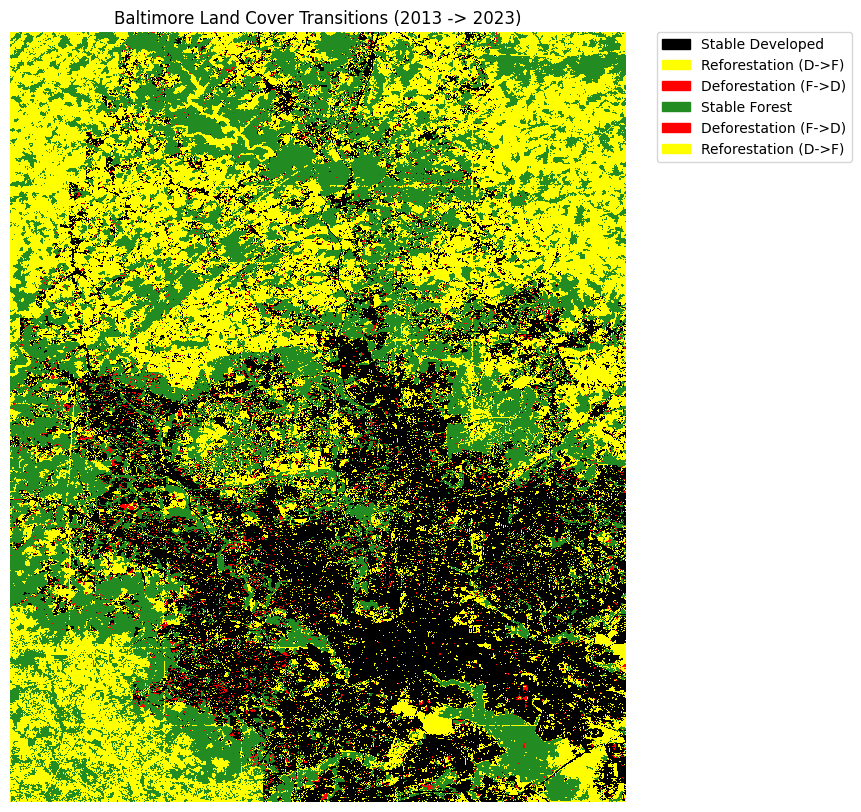

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1. Define the transitions based on your LULC indices
# Indices: 1=Water, 2=Developed, 3=Forest, 4=Ag
# Change logic: (T1 * 10) + T2
transition_defs = {
    11: ("Stable Developed", "black"),
    22: ("Stable Forest", "forestgreen"),
    21: ("Deforestation (F->D)", "red"),
    31: ("Deforestation (F->D)", "red"),
    12: ("Reforestation (D->F)", "yellow"),
    32: ("Reforestation (D->F)", "yellow"),

}

# 2. Setup colors and boundaries
# We need to create a map that explicitly links the code (e.g. 32) to a color
vals = sorted(transition_defs.keys())
colors = [transition_defs[v][1] for v in vals]
labels = [transition_defs[v][0] for v in vals]

custom_cmap = ListedColormap(colors)
# Create boundaries that "wrap" around your specific values
# This ensures that value 22 gets color 0, value 23 gets color 1, etc.
norm = BoundaryNorm(vals + [max(vals)+1], custom_cmap.N)

# 3. Plotting
plt.figure(figsize=(12, 10))

# Use the norm to prevent color bleeding/shifting
im = plt.imshow(
    change_map_small.squeeze(),
    cmap=custom_cmap,
    norm=norm,
    interpolation='nearest'
)

# 4. Add a custom legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title("Baltimore Land Cover Transitions (2013 -> 2023)")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np

# Assuming 3 is Forest and 2 is Developed (from our previous mapping)
# (3 * 10) + 2 = 32
deforestation_code = 32
stable_forest_code = 33

# Get pixel counts from the change map
values, counts = np.unique(change_map.values, return_counts=True)
counts_dict = dict(zip(values, counts))

# 1. Get the number of deforested pixels
deforested_pixels = counts_dict.get(deforestation_code, 0)

# 2. Get the number of stable forest pixels (for percentage calculation)
stable_forest_pixels = counts_dict.get(stable_forest_code, 0)

# 3. Calculate Area
# If resolution is 1m, area_sq_m = pixel_count
area_sq_m = deforested_pixels
area_acres = area_sq_m * 0.000247105
area_sq_km = area_sq_m / 1_000_000

# 4. Calculate Percentage of Forest Lost
total_initial_forest = deforested_pixels + stable_forest_pixels
percent_lost = (deforested_pixels / total_initial_forest) * 100 if total_initial_forest > 0 else 0

print(f"--- Baltimore Deforestation Stats ---")
print(f"Total Area Lost: {area_acres:.2f} acres")
print(f"Total Area Lost: {area_sq_km:.4f} sq km")
print(f"Percentage of 2013 Forest lost by 2023: {percent_lost:.2f}%")

--- Baltimore Deforestation Stats ---
Total Area Lost: 4018.41 acres
Total Area Lost: 16.2620 sq km
Percentage of 2013 Forest lost by 2023: 34.02%


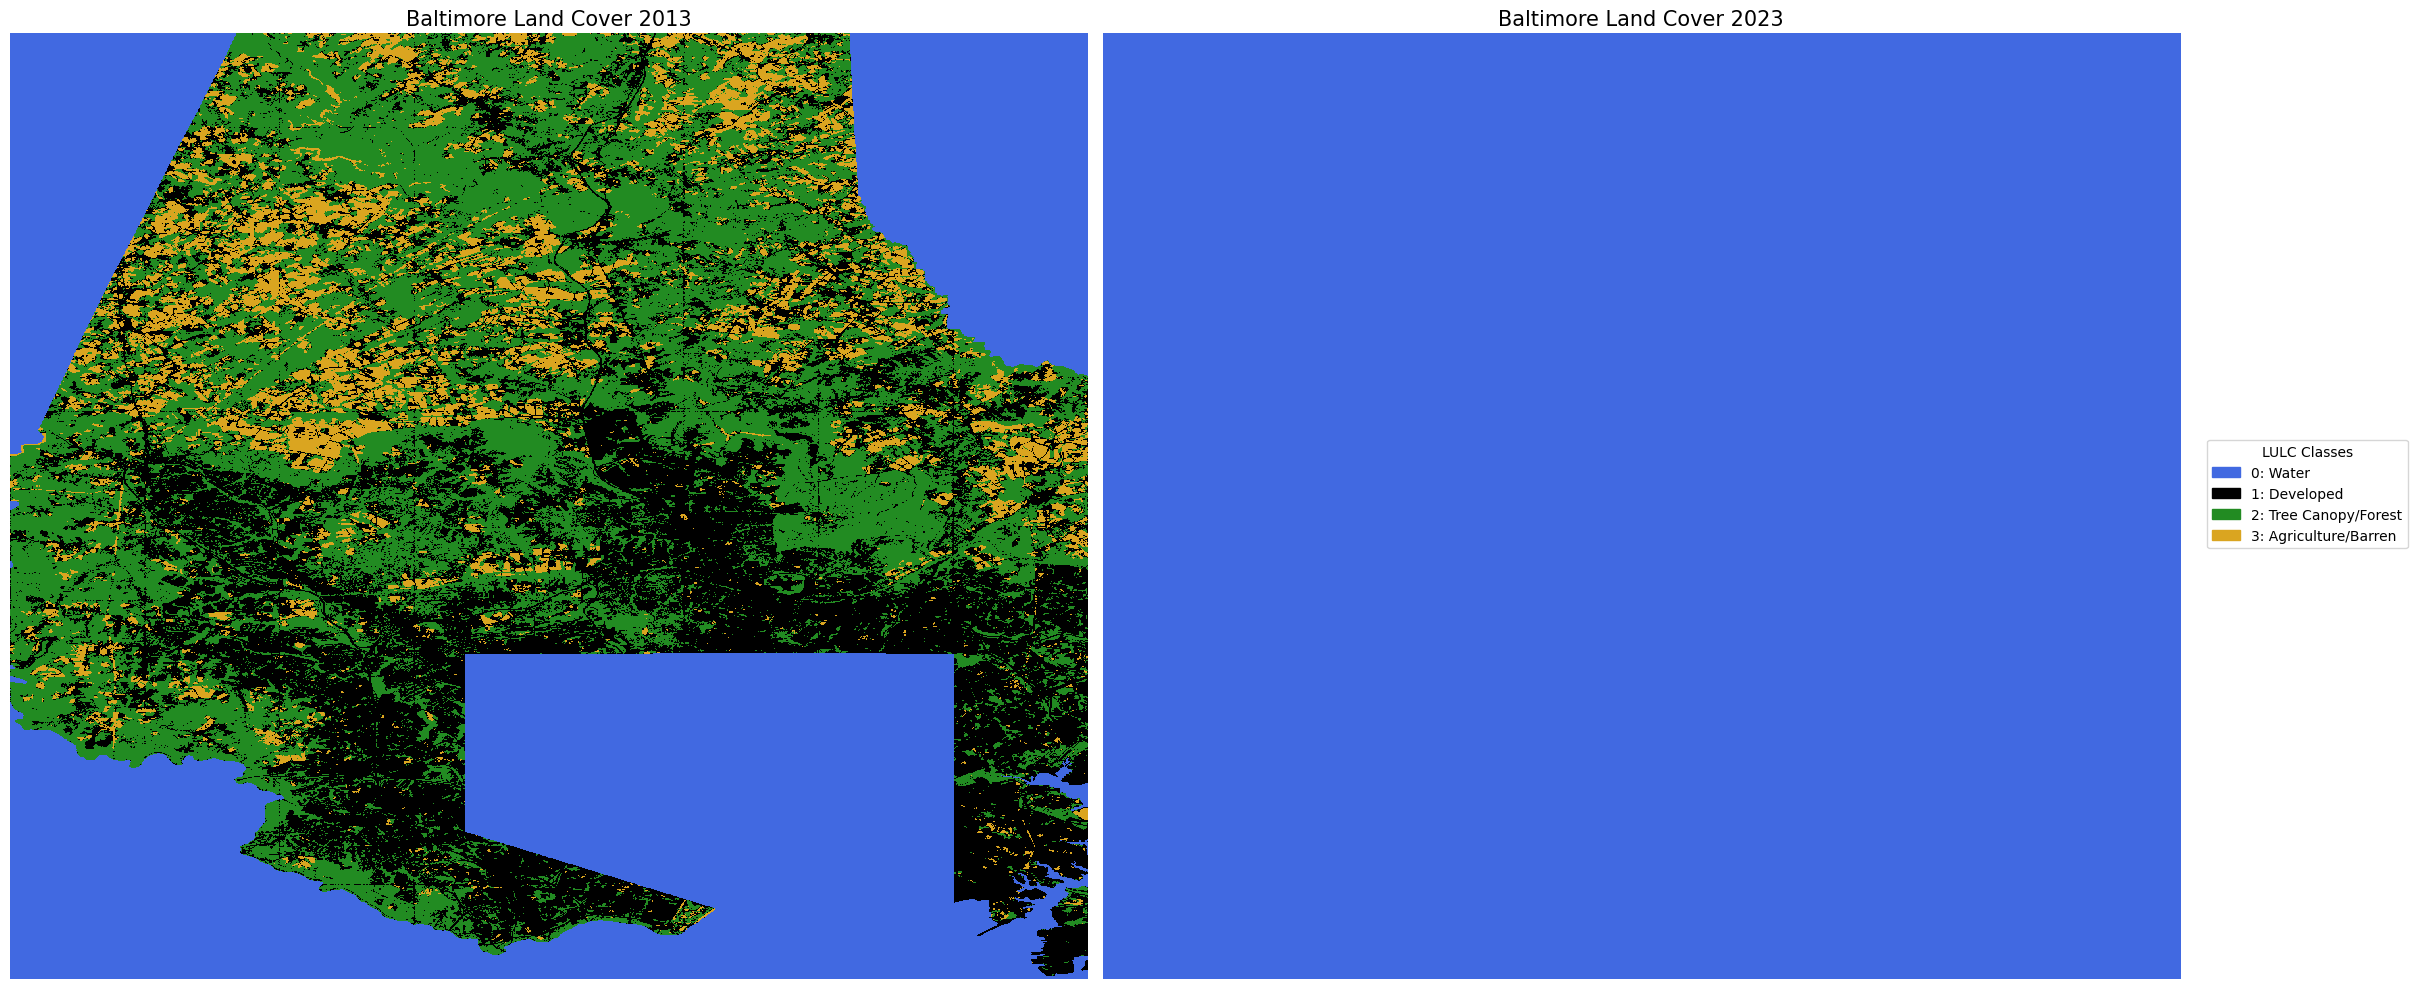

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import rioxarray

# 1. Define your Land Cover Key (Aligning with your 0-4 indices)
# It's best to have 0 as Background/Unlabeled so it doesn't overlap with real data
land_cover_key = {
    0: ("Water", "royalblue"),
    1: ("Developed", "black"),
    2: ("Tree Canopy/Forest", "forestgreen"),
    3: ("Agriculture/Barren", "goldenrod"),
}

# Extract colors and labels
num_classes = len(land_cover_key)
colors = [land_cover_key[i][1] for i in range(num_classes)]
labels = [land_cover_key[i][0] for i in range(num_classes)]
custom_cmap = ListedColormap(colors)

# CRITICAL: Define boundaries so integers map exactly to colors
# This prevents "Blue" from stretching across multiple class IDs
bounds = list(range(num_classes + 1)) # [0, 1, 2, 3, 4, 5]
norm = BoundaryNorm(bounds, custom_cmap.N)

# 2. Load the combined TIFFs
pred_2013 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2013_clipped.tif", chunks=True).squeeze()
pred_2023 = rioxarray.open_rasterio("/content/drive/MyDrive/predicted_county/baltimore_full_landcover_2023_clipped.tif", chunks=True).squeeze()

# Downsample for visualization speed
# Using 'nearest' resampling is vital for categorical data (land cover)
pred_2013_ds = pred_2013.rio.reproject(pred_2013.rio.crs,
                                       shape=(pred_2013.rio.height // 10, pred_2013.rio.width // 10),
                                       resampling=0) # 0 = nearest
pred_2023_ds = pred_2023.rio.reproject(pred_2023.rio.crs,
                                       shape=(pred_2023.rio.height // 10, pred_2023.rio.width // 10),
                                       resampling=0)

# 3. Create the Side-by-Side Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Plot 2013 - Use 'norm' and remove vmin/vmax
pred_2013_ds.plot.imshow(ax=ax1, cmap=custom_cmap, norm=norm, add_colorbar=False, interpolation='nearest')
ax1.set_title("Baltimore Land Cover 2013", fontsize=15)
ax1.axis('off')

# Plot 2023
pred_2023_ds.plot.imshow(ax=ax2, cmap=custom_cmap, norm=norm, add_colorbar=False, interpolation='nearest')
ax2.set_title("Baltimore Land Cover 2023", fontsize=15)
ax2.axis('off')

# 4. Add the Custom Legend
legend_patches = [mpatches.Patch(color=colors[i], label=f"{i}: {labels[i]}") for i in range(num_classes)]
fig.legend(handles=legend_patches, loc='center right', bbox_to_anchor=(1.1, 0.5), title="LULC Classes")

plt.tight_layout()
plt.show()

In [ ]:
# Inside your loop, before saving:
print(pred_t1.shape)

(20480, 16384)


In [ ]:
shutil.copytree("predicted_county", "/content/drive/MyDrive/Baltimore_GeoAI/predicted_county")